# Medical Imaging Dataset Analysis

Comprehensive analysis and visualization of tumor imaging datasets.

## Datasets Analyzed:
- **CRLM**: Colorectal Liver Metastases (CT)
- **Desmoid**: Desmoid Tumors (CT)
- **GIST**: Gastrointestinal Stromal Tumors (CT)
- **Lipo**: Liposarcoma (MRI)
- **Liver**: Liver Tumors (CT)
- **Melanoma**: Melanoma (CT)

In [1]:
import sys
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Setup paths
project_root = Path.cwd().resolve()
while project_root.parent != project_root and not (project_root / 'configs').exists():
    project_root = project_root.parent

configs_dir = project_root / 'configs'
if not configs_dir.exists():
    raise FileNotFoundError("Unable to locate 'configs' directory from current working directory")

sys.path.insert(0, str(project_root))

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

In [2]:
# Load dataset configuration
config_path = configs_dir / 'datasets_analysis.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

print(f"✅ Loaded config for {len(config['datasets'])} datasets")
for name, info in config['datasets'].items():
    print(f"  - {name.upper()}: {info['description']} ({info['modality']})")

✅ Loaded config for 6 datasets
  - CRLM: Colorectal Liver Metastases (CT)
  - DESMOID: Desmoid Tumors (CT)
  - GIST: Gastrointestinal Stromal Tumors (CT)
  - LIPO: Liposarcoma (MRI) (MR)
  - LIVER: Liver Tumors (CT)
  - MELANOMA: Melanoma (CT)


In [3]:
def find_dataset_files(dataset_config, project_root):
    """Find all images and labels for a dataset, properly paired."""
    category = dataset_config['category']
    ct_name = dataset_config['ct_name']
    
    # Main paths to check
    sam3d_root = project_root / 'SAM-Med3D-main' / 'SAM-Med3D-main'
    data_root = project_root / 'data'
    
    # First try SAM-Med3D processed data (already paired 1:1)
    processed_paths = [
        (sam3d_root / 'data' / 'train' / category / ct_name / 'imagesTr',
         sam3d_root / 'data' / 'train' / category / ct_name / 'labelsTr'),
        (sam3d_root / 'data' / 'validation' / category / ct_name / 'imagesVal',
         sam3d_root / 'data' / 'validation' / category / ct_name / 'labelsVal'),
    ]
    
    for img_path, lbl_path in processed_paths:
        if img_path.exists() and lbl_path.exists():
            images = sorted(img_path.glob('*.nii.gz'))
            labels = sorted(lbl_path.glob('*.nii.gz'))
            if images and labels:
                print(f"  ✓ Found {len(images)} processed images at: {img_path}")
                print(f"  ✓ Found {len(labels)} processed labels at: {lbl_path}")
                return images, labels
    
    # Try raw data - need to find case directories and pair properly
    raw_data_path = data_root / category
    if raw_data_path.exists():
        # Find all case directories (e.g., GIST-001_CT, CRLM-005_CT, etc.)
        case_dirs = sorted(raw_data_path.glob('*_CT')) + sorted(raw_data_path.glob('*_MR'))
        
        images, labels = [], []
        for case_dir in case_dirs:
            # Look for NIFTI directory
            nifti_dir = case_dir / '1' / 'NIFTI'
            if not nifti_dir.exists():
                nifti_dir = case_dir / 'NIFTI'
            
            if nifti_dir.exists():
                # Find image (usually just one: image.nii.gz)
                img_files = list(nifti_dir.glob('image.nii.gz'))
                if not img_files:
                    img_files = list(nifti_dir.glob('image_lesion_*.nii.gz'))
                
                # Find segmentation (may be one or multiple lesion files)
                seg_files = list(nifti_dir.glob('segmentation.nii.gz'))
                if not seg_files:
                    seg_files = list(nifti_dir.glob('segmentation_lesion_*.nii.gz'))
                if not seg_files:
                    seg_files = list(nifti_dir.glob('segmentation_*.nii.gz'))
                
                # Only add if we have both image and at least one segmentation
                if img_files and seg_files:
                    images.append(img_files[0])  # Take first/main image
                    labels.append(seg_files[0])  # Take first segmentation as representative
        
        if images and labels:
            print(f"  ✓ Found {len(images)} raw cases at: {raw_data_path}")
            print(f"  ℹ️  Note: Multiple lesion masks per case merged into single count")
            return images, labels
    
    # Cluster paths (already processed 1:1)
    cluster_paths = [
        (Path(f'/data/scratch/r112276/{category}/{ct_name}/imagesTr'),
         Path(f'/data/scratch/r112276/{category}/{ct_name}/labelsTr')),
    ]
    
    for img_path, lbl_path in cluster_paths:
        if img_path.exists() and lbl_path.exists():
            images = sorted(img_path.glob('*.nii.gz'))
            labels = sorted(lbl_path.glob('*.nii.gz'))
            if images and labels:
                print(f"  ✓ Found {len(images)} cluster images at: {img_path}")
                print(f"  ✓ Found {len(labels)} cluster labels at: {lbl_path}")
                return images, labels
    
    return [], []
def load_nifti_info(file_path):
    """Load NIfTI file and return basic info."""
    nii = nib.load(file_path)
    data = nii.get_fdata()
    return {
        'shape': data.shape,
        'min': float(data.min()),
        'max': float(data.max()),
        'mean': float(data.mean()),
        'std': float(data.std()),
        'spacing': nii.header.get_zooms()[:3],
        'data': data
    }

print("✅ Helper functions loaded")

✅ Helper functions loaded


In [4]:
print("📊 Collecting dataset statistics...\n")

dataset_stats = {}

for dataset_name, dataset_config in config['datasets'].items():
    print(f"Analyzing {dataset_name.upper()}...")
    
    images, labels = find_dataset_files(dataset_config, project_root)
    
    stats = {
        'name': dataset_name,
        'description': dataset_config['description'],
        'modality': dataset_config['modality'],
        'n_images': len(images),
        'n_labels': len(labels),
        'expected': dataset_config.get('expected_samples', 'N/A'),
        'shapes': [],
        'spacings': [],
        'intensities': {'min': [], 'max': [], 'mean': [], 'std': []},
        'tumor_volumes_voxels': [],
        'tumor_volumes_mm3': [],
        'tumor_volumes_cm3': []
    }
    
    # Sample a few images for detailed analysis
    sample_size = min(10, len(images))
    for img_path, label_path in zip(images[:sample_size], labels[:sample_size]):
        try:
            img_info = load_nifti_info(img_path)
            stats['shapes'].append(img_info['shape'])
            stats['spacings'].append(img_info['spacing'])
            stats['intensities']['min'].append(img_info['min'])
            stats['intensities']['max'].append(img_info['max'])
            stats['intensities']['mean'].append(img_info['mean'])
            stats['intensities']['std'].append(img_info['std'])
            
            if label_path.exists():
                label_data = nib.load(label_path).get_fdata()
                tumor_voxels = (label_data > 0).sum()
                
                # Calculate physical volume using spacing
                voxel_volume_mm3 = np.prod(img_info['spacing'])  # mm³ per voxel
                tumor_volume_mm3 = tumor_voxels * voxel_volume_mm3
                tumor_volume_cm3 = tumor_volume_mm3 / 1000  # Convert to cm³
                
                stats['tumor_volumes_voxels'].append(tumor_voxels)
                stats['tumor_volumes_mm3'].append(tumor_volume_mm3)
                stats['tumor_volumes_cm3'].append(tumor_volume_cm3)
        except Exception as e:
            print(f"  ⚠️  Error loading {img_path.name}: {e}")
    
    dataset_stats[dataset_name] = stats
    print(f"  Found {stats['n_images']} images, {stats['n_labels']} labels\n")

print("✅ Statistics collection complete!")

📊 Collecting dataset statistics...

Analyzing CRLM...
  ✓ Found 77 raw cases at: C:\Users\cahel\Desktop\Med3Tab-PFN\data\crlm
  ℹ️  Note: Multiple lesion masks per case merged into single count
  Found 77 images, 77 labels

Analyzing DESMOID...
  ✓ Found 203 raw cases at: C:\Users\cahel\Desktop\Med3Tab-PFN\data\desmoid
  ℹ️  Note: Multiple lesion masks per case merged into single count
  Found 203 images, 203 labels

Analyzing GIST...
  ✓ Found 246 processed images at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST\imagesTr
  ✓ Found 246 processed labels at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST\labelsTr
  Found 246 images, 246 labels

Analyzing LIPO...
  ✓ Found 115 processed images at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\lipo\ct_LIPO\imagesTr
  ✓ Found 115 processed labels at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\l

In [5]:
# Create summary DataFrame
summary_data = []
for name, stats in dataset_stats.items():
    summary_data.append({
        'Dataset': name.upper(),
        'Description': stats['description'],
        'Modality': stats['modality'],
        'Images': stats['n_images'],
        'Labels': stats['n_labels'],
        'Expected': stats['expected']
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("📋 DATASET SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)
print(f"\nTotal datasets: {len(summary_df)}")
print(f"Total images: {summary_df['Images'].sum()}")
print(f"CT scans: {len(summary_df[summary_df['Modality'] == 'CT'])}")
print(f"MR scans: {len(summary_df[summary_df['Modality'] == 'MR'])}")


📋 DATASET SUMMARY
 Dataset                     Description Modality  Images  Labels  Expected
    CRLM     Colorectal Liver Metastases       CT      77      77        77
 DESMOID                  Desmoid Tumors       CT     203     203       203
    GIST Gastrointestinal Stromal Tumors       CT     246     246       246
    LIPO               Liposarcoma (MRI)       MR     115     115       115
   LIVER                    Liver Tumors       CT     186     186       186
MELANOMA                        Melanoma       CT     103     103       103

Total datasets: 6
Total images: 930
CT scans: 5
MR scans: 1


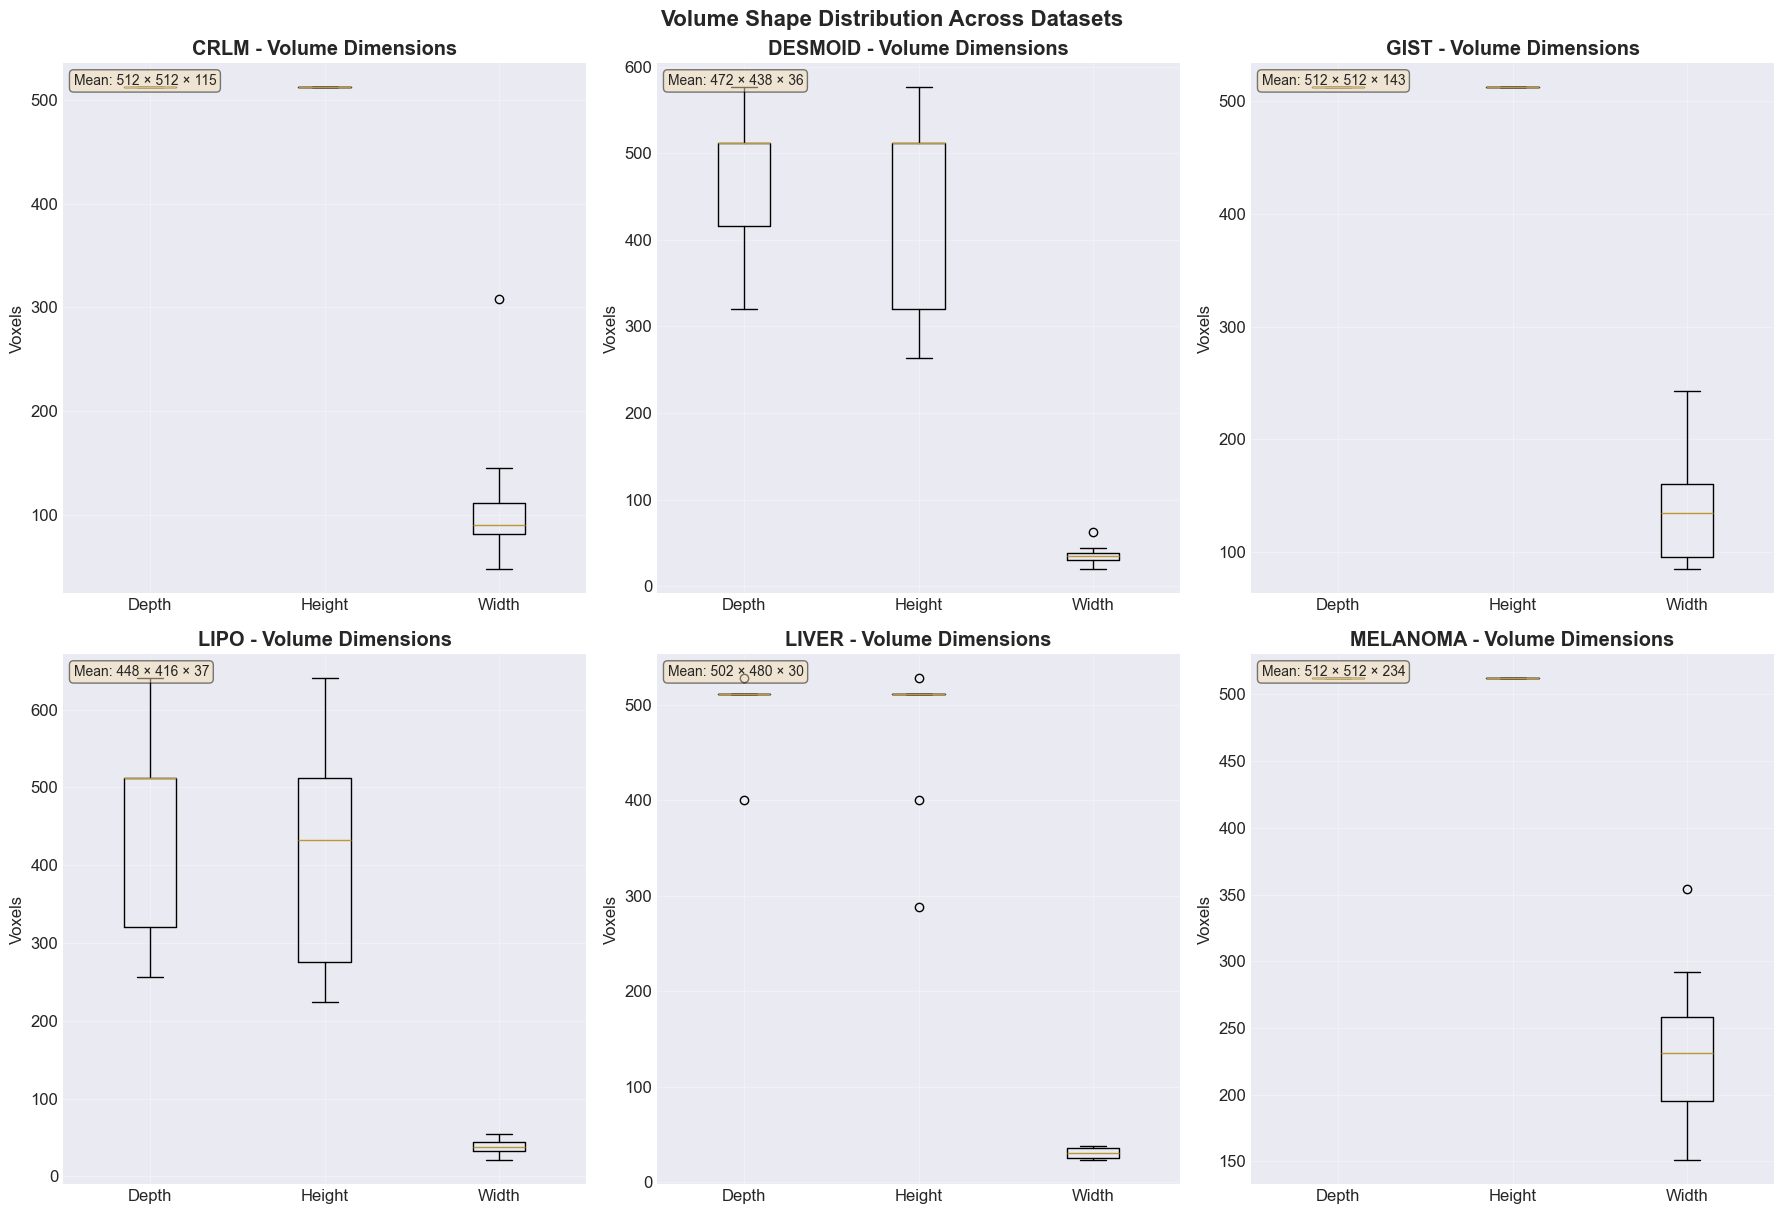

In [6]:
# Analyze volume shapes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, stats) in enumerate(dataset_stats.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    
    if stats['shapes']:
        shapes_array = np.array(stats['shapes'])
        
        ax.boxplot([shapes_array[:, 0], shapes_array[:, 1], shapes_array[:, 2]],
                   labels=['Depth', 'Height', 'Width'])
        ax.set_title(f"{name.upper()} - Volume Dimensions", fontweight='bold')
        ax.set_ylabel('Voxels')
        ax.grid(True, alpha=0.3)
        
        # Add mean values as text
        means = shapes_array.mean(axis=0)
        ax.text(0.02, 0.98, f"Mean: {means[0]:.0f} × {means[1]:.0f} × {means[2]:.0f}",
                transform=ax.transAxes, va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f"{name.upper()} - No data")

plt.tight_layout()
plt.suptitle('Volume Shape Distribution Across Datasets', 
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

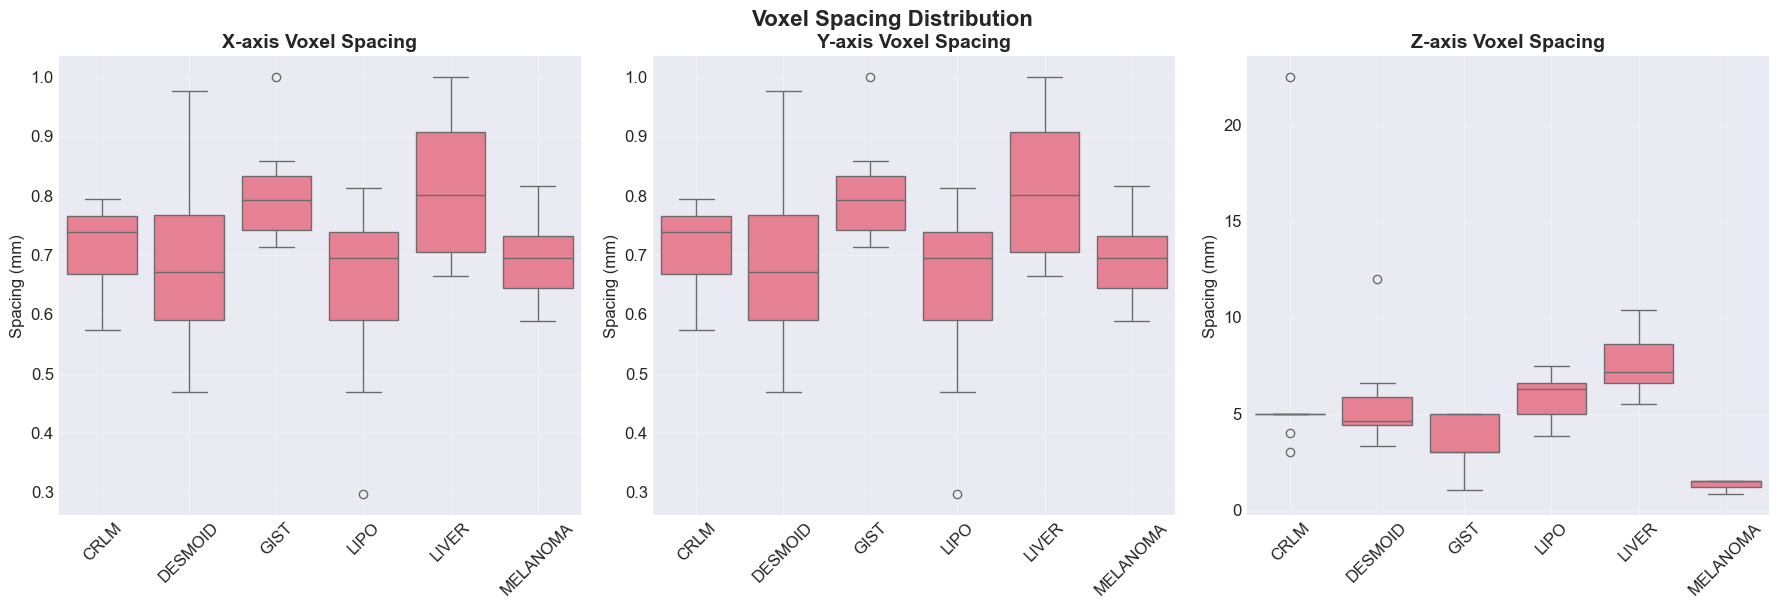

In [7]:
# Voxel spacing analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

spacing_data = []
for name, stats in dataset_stats.items():
    for spacing in stats['spacings']:
        spacing_data.append({
            'Dataset': name.upper(),
            'X': spacing[0],
            'Y': spacing[1],
            'Z': spacing[2]
        })

spacing_df = pd.DataFrame(spacing_data)

for idx, dim in enumerate(['X', 'Y', 'Z']):
    ax = axes[idx]
    sns.boxplot(data=spacing_df, x='Dataset', y=dim, ax=ax)
    ax.set_title(f'{dim}-axis Voxel Spacing', fontweight='bold', fontsize=14)
    ax.set_ylabel('Spacing (mm)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Voxel Spacing Distribution',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

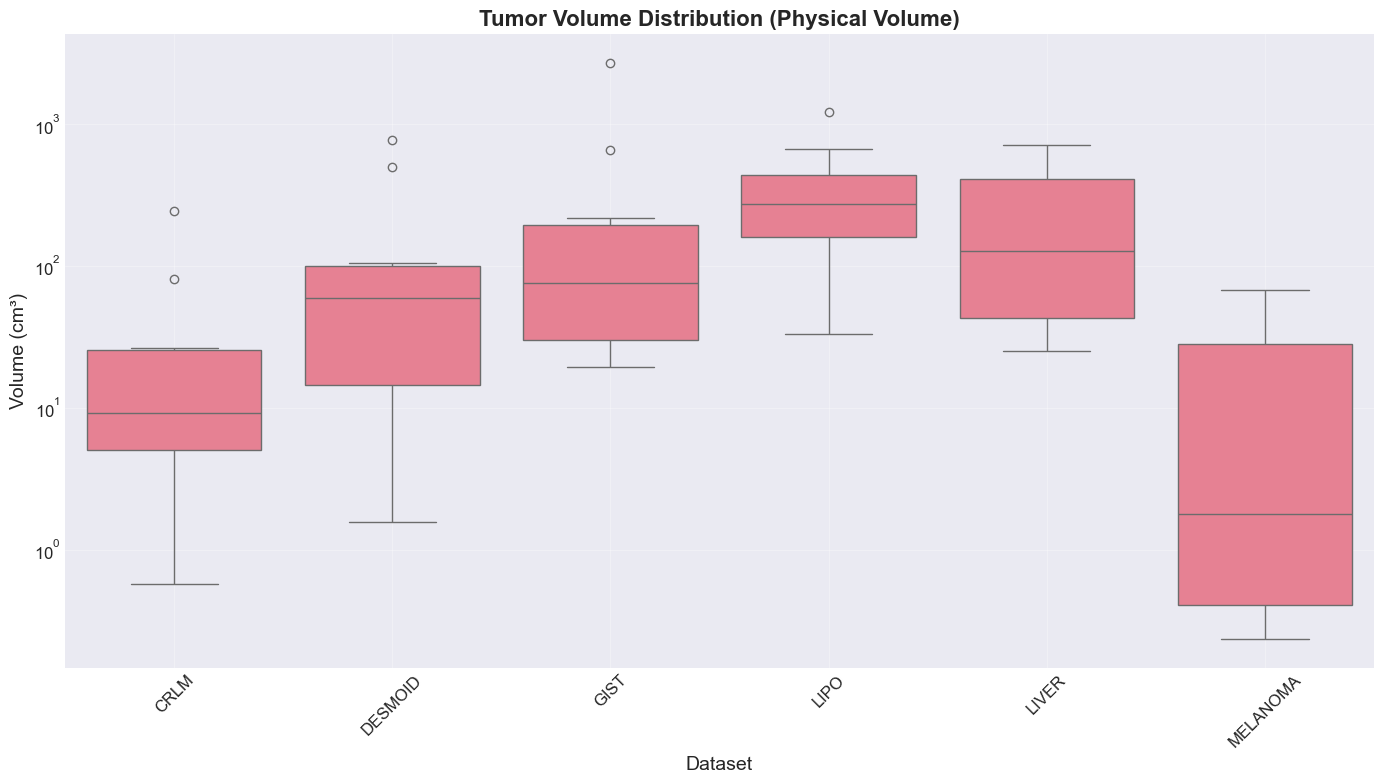


Tumor Volume Statistics (Physical Volumes):
          count        mean         std        min         25%         50%  \
Dataset                                                                      
CRLM       10.0   40.489409   74.882458   0.574219    5.015793    9.261686   
DESMOID    10.0  161.601561  260.560214   1.582163   14.511214   59.919704   
GIST       10.0  393.974441  826.143367  19.271439   30.212743   75.240831   
LIPO       10.0  365.682733  355.525285  33.153062  159.867193  273.676928   
LIVER      10.0  250.384767  255.499077  25.346180   43.074707  128.433408   
MELANOMA   10.0   16.141636   23.446101   0.235948    0.407425    1.785478   

                 75%          max  
Dataset                            
CRLM       25.720180   242.590282  
DESMOID    99.975015   775.059357  
GIST      193.401696  2680.526216  
LIPO      434.826761  1223.064874  
LIVER     408.159203   717.009227  
MELANOMA   28.012963    67.614848  

Tumor Volume Statistics (Voxel Counts for

In [8]:
# Tumor volume analysis (physical volumes in cm³)
fig, ax = plt.subplots(figsize=(14, 8))

tumor_data = []
for name, stats in dataset_stats.items():
    for vol_cm3, vol_voxels in zip(stats.get('tumor_volumes_cm3', []), 
                                    stats.get('tumor_volumes_voxels', stats.get('tumor_volumes', []))):
        tumor_data.append({
            'Dataset': name.upper(),
            'Volume (cm³)': vol_cm3,
            'Volume (voxels)': vol_voxels
        })

if tumor_data:
    tumor_df = pd.DataFrame(tumor_data)
    sns.boxplot(data=tumor_df, x='Dataset', y='Volume (cm³)', ax=ax)
    ax.set_title('Tumor Volume Distribution (Physical Volume)', fontweight='bold', fontsize=16)
    ax.set_ylabel('Volume (cm³)', fontsize=14)
    ax.set_xlabel('Dataset', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nTumor Volume Statistics (Physical Volumes):")
    print(tumor_df.groupby('Dataset')['Volume (cm³)'].describe())
    print("\nTumor Volume Statistics (Voxel Counts for reference):")
    print(tumor_df.groupby('Dataset')['Volume (voxels)'].describe())
else:
    print("No tumor volume data available")

## Sample Visualizations

Let's visualize some sample slices from each dataset

In [9]:
def visualize_sample(img_path, label_path, title):
    """Visualize a single sample with tumor mask."""
    img_data = nib.load(img_path).get_fdata()
    label_data = nib.load(label_path).get_fdata() if label_path.exists() else None
    
    # Get middle slices
    d, h, w = img_data.shape
    slices = [d//2, h//2, w//2]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Axial
    axes[0, 0].imshow(img_data[slices[0], :, :], cmap='gray')
    axes[0, 0].set_title('Axial - Image')
    axes[0, 0].axis('off')
    
    if label_data is not None:
        axes[1, 0].imshow(img_data[slices[0], :, :], cmap='gray')
        axes[1, 0].imshow(label_data[slices[0], :, :], cmap='Reds', alpha=0.5)
        axes[1, 0].set_title('Axial - With Tumor')
    axes[1, 0].axis('off')
    
    # Coronal
    axes[0, 1].imshow(img_data[:, slices[1], :], cmap='gray')
    axes[0, 1].set_title('Coronal - Image')
    axes[0, 1].axis('off')
    
    if label_data is not None:
        axes[1, 1].imshow(img_data[:, slices[1], :], cmap='gray')
        axes[1, 1].imshow(label_data[:, slices[1], :], cmap='Reds', alpha=0.5)
        axes[1, 1].set_title('Coronal - With Tumor')
    axes[1, 1].axis('off')
    
    # Sagittal
    axes[0, 2].imshow(img_data[:, :, slices[2]], cmap='gray')
    axes[0, 2].set_title('Sagittal - Image')
    axes[0, 2].axis('off')
    
    if label_data is not None:
        axes[1, 2].imshow(img_data[:, :, slices[2]], cmap='gray')
        axes[1, 2].imshow(label_data[:, :, slices[2]], cmap='Reds', alpha=0.5)
        axes[1, 2].set_title('Sagittal - With Tumor')
    axes[1, 2].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("✅ Visualization helper ready")

✅ Visualization helper ready


## Detailed Dimension Analysis

Histograms showing the distribution of image dimensions for each dataset

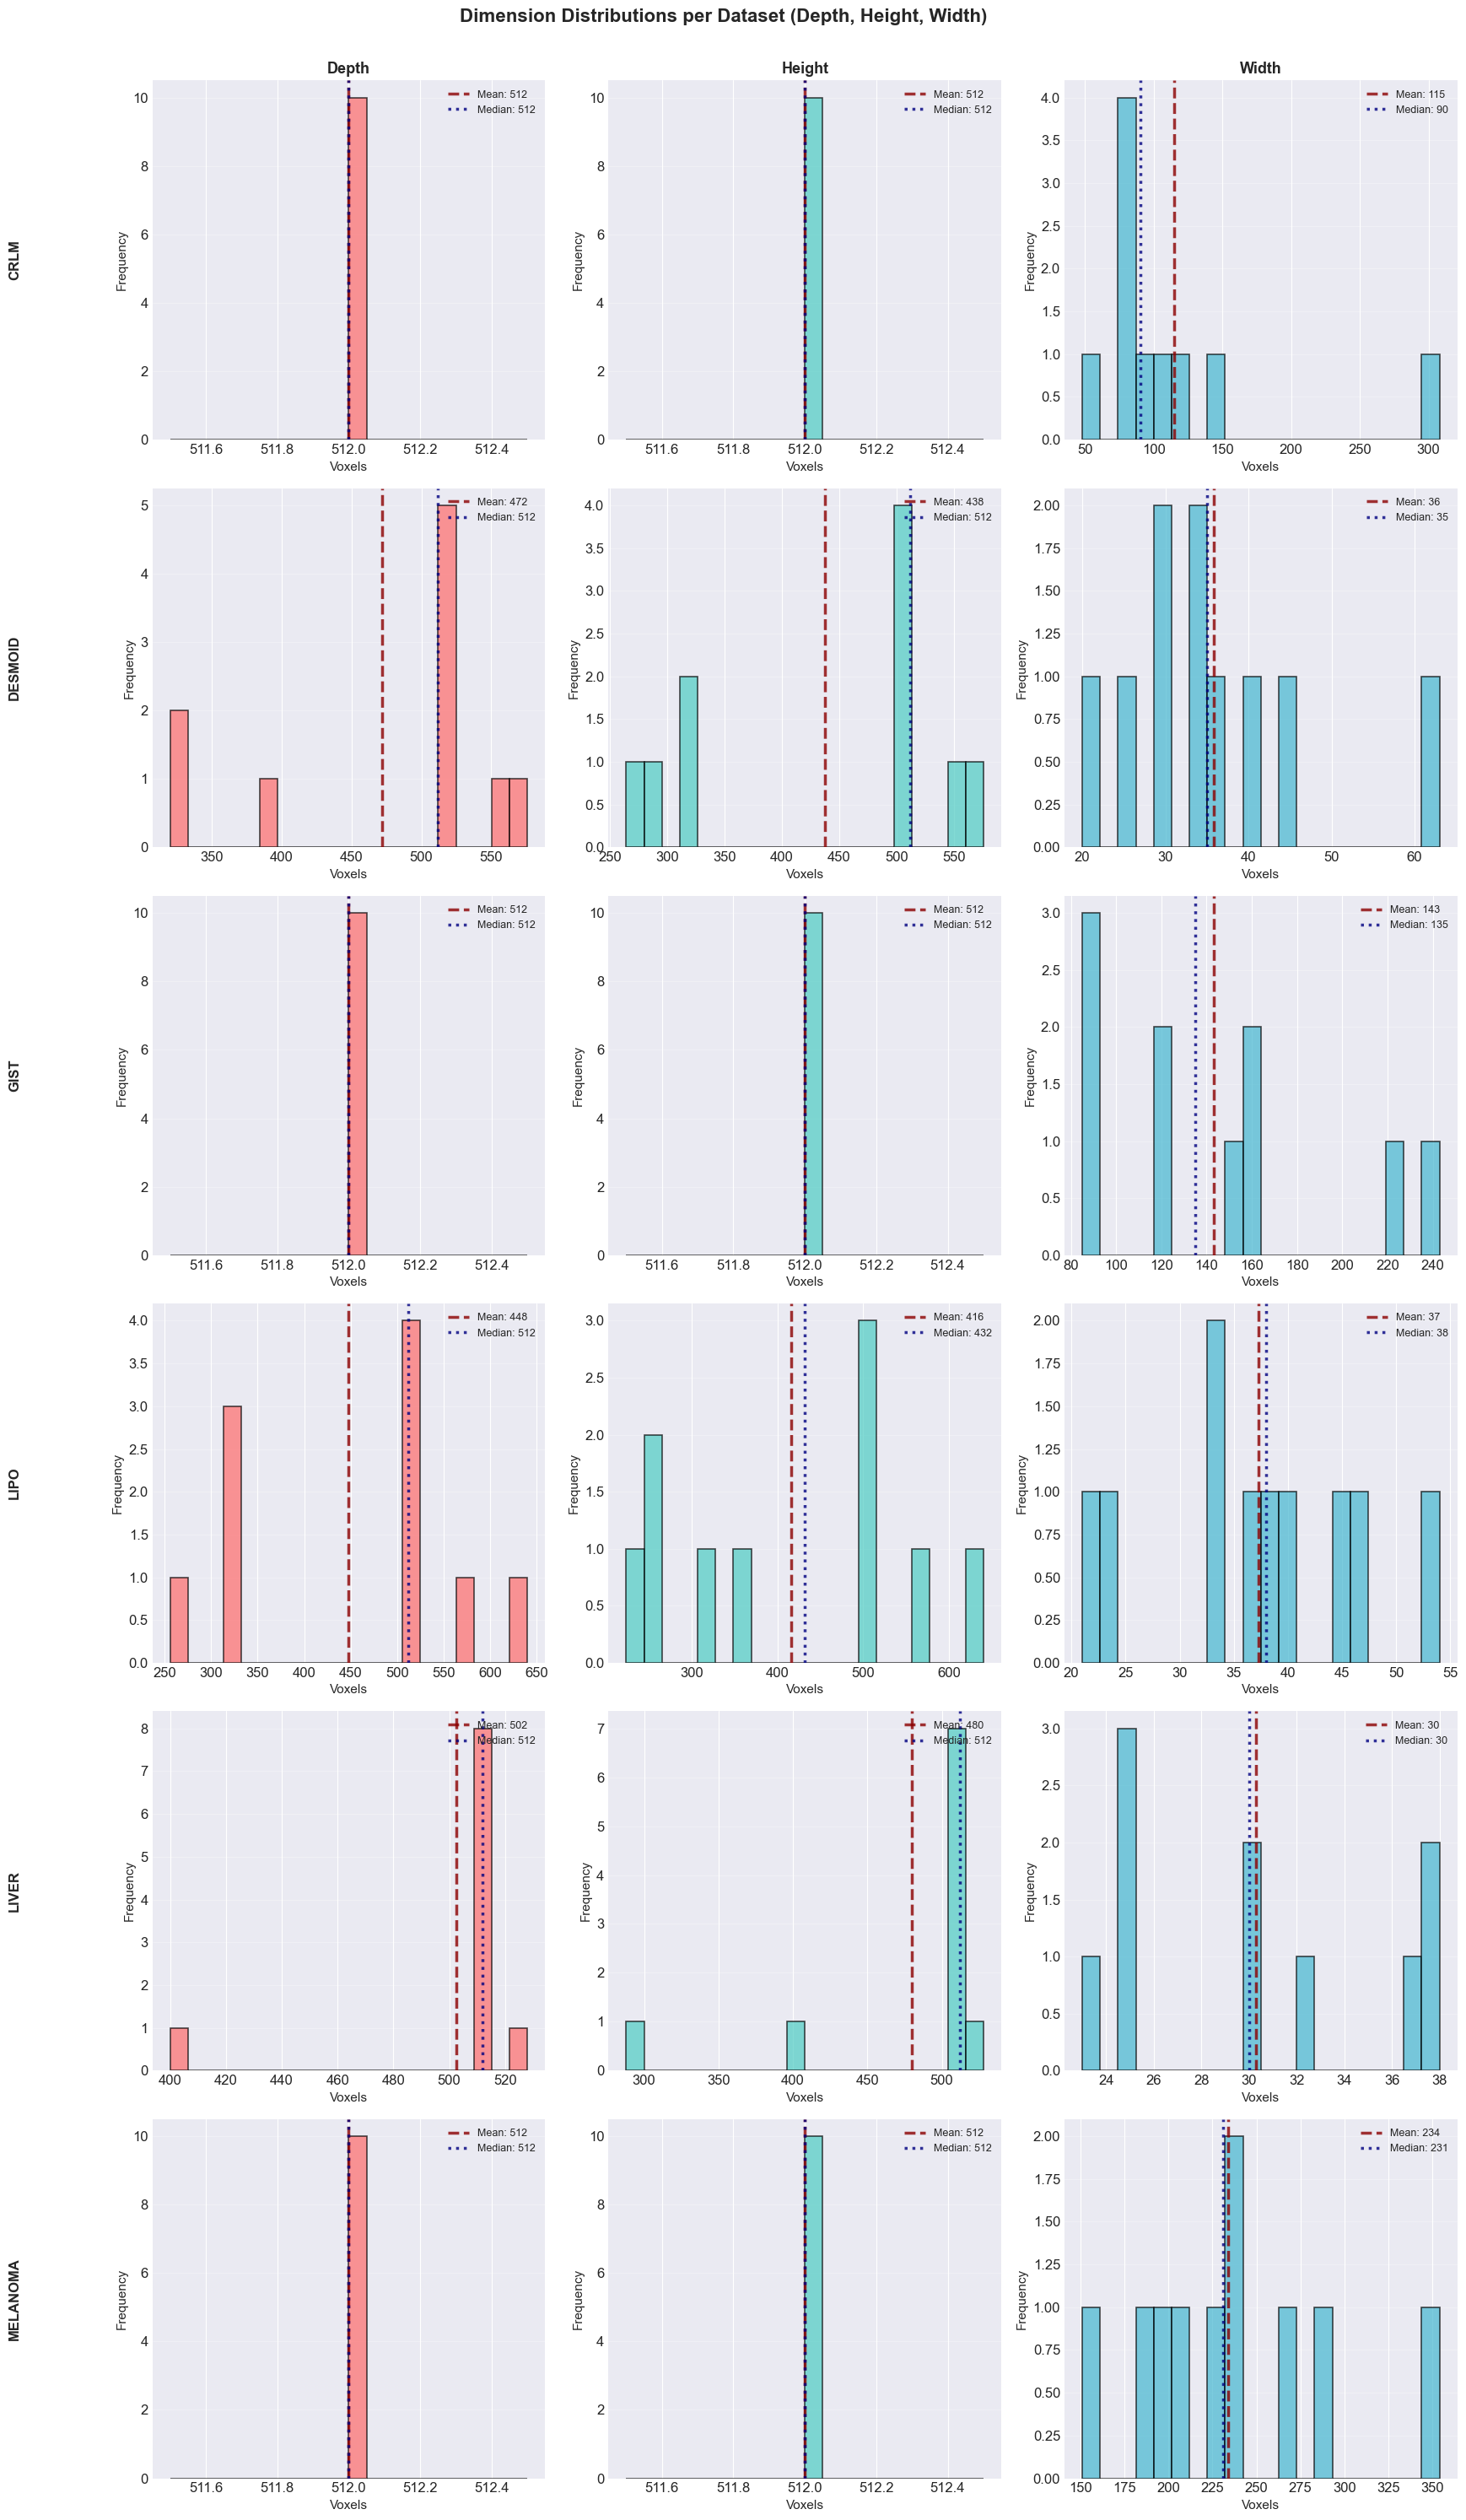


DIMENSION STATISTICS BY DATASET

CRLM:
  Depth   : mean=  512.0, median=  512.0, std=   0.0, min=   512, max=   512, range=     0
  Height  : mean=  512.0, median=  512.0, std=   0.0, min=   512, max=   512, range=     0
  Width   : mean=  114.6, median=   90.5, std=  68.9, min=    48, max=   308, range=   260

DESMOID:
  Depth   : mean=  472.0, median=  512.0, std=  89.7, min=   320, max=   576, range=   256
  Height  : mean=  437.6, median=  512.0, std= 116.8, min=   264, max=   576, range=   312
  Width   : mean=   35.8, median=   35.0, std=  11.2, min=    20, max=    63, range=    43

GIST:
  Depth   : mean=  512.0, median=  512.0, std=   0.0, min=   512, max=   512, range=     0
  Height  : mean=  512.0, median=  512.0, std=   0.0, min=   512, max=   512, range=     0
  Width   : mean=  143.2, median=  135.0, std=  52.5, min=    85, max=   243, range=   158

LIPO:
  Depth   : mean=  448.0, median=  512.0, std= 124.8, min=   256, max=   640, range=   384
  Height  : mean=  416.4, 

In [10]:
# Dimension histograms - 3 histograms per dataset showing D, H, W distributions
n_datasets = len(dataset_stats)
fig, axes = plt.subplots(n_datasets, 3, figsize=(18, 5*n_datasets))

# Ensure axes is 2D even if only one dataset
if n_datasets == 1:
    axes = axes.reshape(1, -1)

dimensions = ['Depth', 'Height', 'Width']
dim_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Red, Teal, Blue

for row_idx, (name, stats) in enumerate(dataset_stats.items()):
    if stats['shapes']:
        shapes_array = np.array(stats['shapes'])
        
        for col_idx, (dimension, color) in enumerate(zip(dimensions, dim_colors)):
            ax = axes[row_idx, col_idx]
            
            # Get data for this dimension
            dim_data = shapes_array[:, col_idx]
            
            # Create histogram
            ax.hist(dim_data, bins=20, color=color, alpha=0.7, edgecolor='black', linewidth=1.2)
            
            # Add statistics
            mean_val = np.mean(dim_data)
            median_val = np.median(dim_data)
            
            # Add vertical lines for mean and median
            ax.axvline(mean_val, color='darkred', linestyle='--', 
                      linewidth=2.5, label=f'Mean: {mean_val:.0f}', alpha=0.8)
            ax.axvline(median_val, color='navy', linestyle=':', 
                      linewidth=2.5, label=f'Median: {median_val:.0f}', alpha=0.8)
            
            # Styling
            ax.set_xlabel('Voxels', fontsize=11)
            ax.set_ylabel('Frequency', fontsize=11)
            
            # Title only on first row
            if row_idx == 0:
                ax.set_title(f'{dimension}', fontweight='bold', fontsize=13)
            
            # Dataset name on left side of first column
            if col_idx == 0:
                ax.text(-0.35, 0.5, name.upper(), transform=ax.transAxes,
                       fontsize=12, fontweight='bold', rotation=90,
                       va='center', ha='center')
            
            ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
            ax.grid(True, alpha=0.3, axis='y')
    else:
        # No data case
        for col_idx in range(3):
            ax = axes[row_idx, col_idx]
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
            if col_idx == 0:
                ax.text(-0.35, 0.5, name.upper(), transform=ax.transAxes,
                       fontsize=12, fontweight='bold', rotation=90,
                       va='center', ha='center')

plt.tight_layout(rect=[0.03, 0, 1, 0.98])  # Leave space for dataset labels
plt.suptitle('Dimension Distributions per Dataset (Depth, Height, Width)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Summary statistics table
print("\n" + "="*80)
print("DIMENSION STATISTICS BY DATASET")
print("="*80)
for name, stats in dataset_stats.items():
    print(f"\n{name.upper()}:")
    if stats['shapes']:
        shapes_array = np.array(stats['shapes'])
        for dim_idx, dimension in enumerate(dimensions):
            values = shapes_array[:, dim_idx]
            print(f"  {dimension:8s}: mean={values.mean():7.1f}, "
                  f"median={np.median(values):7.1f}, "
                  f"std={values.std():6.1f}, "
                  f"min={values.min():6.0f}, "
                  f"max={values.max():6.0f}, "
                  f"range={values.max()-values.min():6.0f}")
    else:
        print("  No data available")
print("="*80)

## Aspect Ratio Analysis

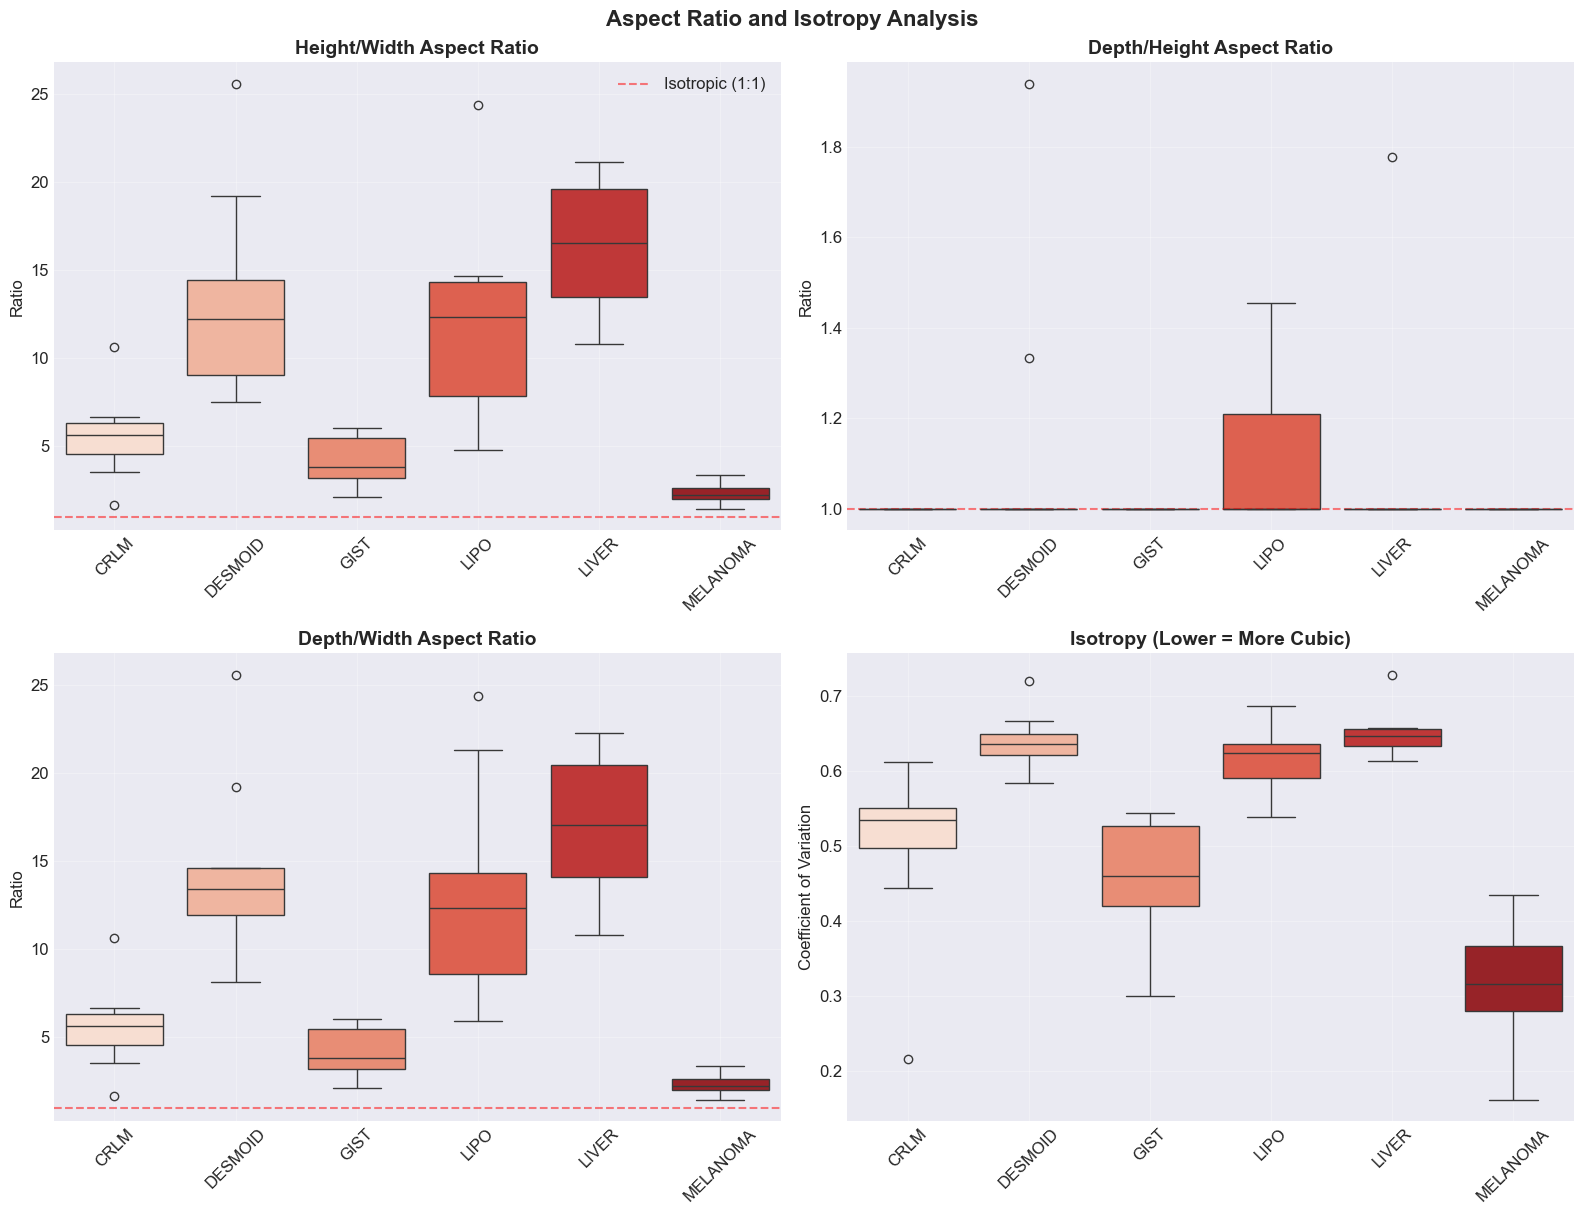


Aspect Ratio Summary:
          Height/Width  Depth/Height  Isotropy
Dataset                                       
CRLM          5.550410      1.000000  0.499842
DESMOID      13.202367      1.127273  0.637540
GIST          4.057763      1.000000  0.450524
LIPO         11.996669      1.107817  0.617485
LIVER        16.249325      1.077778  0.651172
MELANOMA      2.307717      1.000000  0.315789


In [11]:
# Aspect ratio analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

aspect_data = []
for name, stats in dataset_stats.items():
    if stats['shapes']:
        shapes_array = np.array(stats['shapes'])
        for shape in shapes_array:
            d, h, w = shape
            aspect_data.append({
                'Dataset': name.upper(),
                'Height/Width': h / w if w > 0 else 0,
                'Depth/Height': d / h if h > 0 else 0,
                'Depth/Width': d / w if w > 0 else 0,
                'Isotropy': np.std([d, h, w]) / np.mean([d, h, w]) if np.mean([d, h, w]) > 0 else 0
            })

aspect_df = pd.DataFrame(aspect_data)
palette = sns.color_palette('Reds', n_colors=6)

# Plot aspect ratios with consistent boxplots
ratios = ['Height/Width', 'Depth/Height', 'Depth/Width']
for idx, ratio in enumerate(ratios):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=aspect_df, x='Dataset', y=ratio, palette=palette, ax=ax)
    ax.set_title(f'{ratio} Aspect Ratio', fontweight='bold', fontsize=14)
    ax.set_ylabel('Ratio')
    ax.set_xlabel('')
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5,
               label='Isotropic (1:1)' if idx == 0 else None)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(frameon=False)

# Isotropy plot
ax = axes[1, 1]
sns.boxplot(data=aspect_df, x='Dataset', y='Isotropy', palette=palette, ax=ax)
ax.set_title('Isotropy (Lower = More Cubic)', fontweight='bold', fontsize=14)
ax.set_ylabel('Coefficient of Variation')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Aspect Ratio and Isotropy Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.show()

print("\nAspect Ratio Summary:")
print(aspect_df.groupby('Dataset')[['Height/Width', 'Depth/Height', 'Isotropy']].mean())

## Tumor Volume Analysis

Analyzing tumor size relative to total scan volume

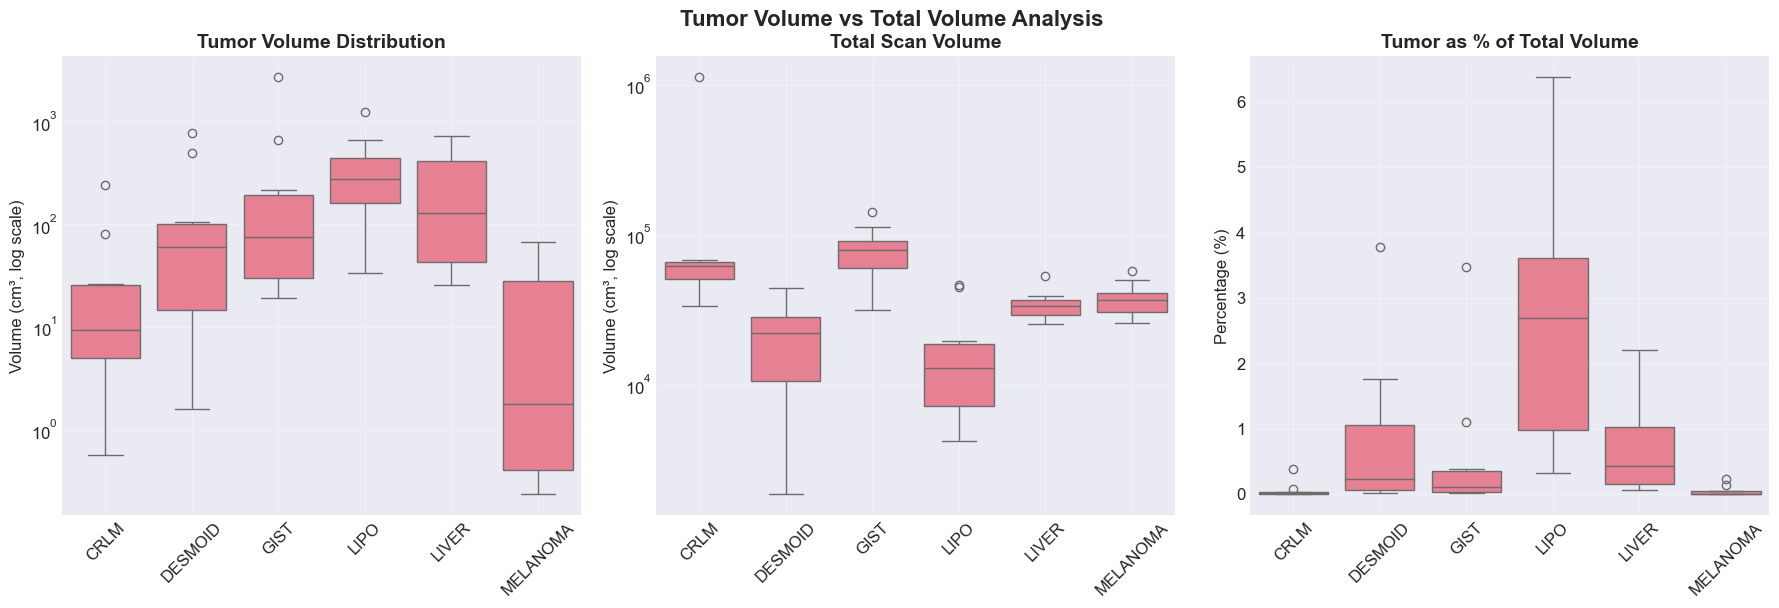


Volume Ratio Statistics:
          count      mean       std       min       25%       50%       75%  \
Dataset                                                                       
CRLM       10.0  0.057568  0.119753  0.001044  0.006674  0.014888  0.034160   
DESMOID    10.0  0.832888  1.192434  0.018865  0.065268  0.228523  1.066596   
GIST       10.0  0.556891  1.075580  0.018692  0.036573  0.109355  0.360119   
LIPO       10.0  2.578856  1.895006  0.323961  0.990901  2.696796  3.619087   
LIVER      10.0  0.721926  0.749113  0.072568  0.164536  0.432662  1.033417   
MELANOMA   10.0  0.048736  0.080235  0.000596  0.001038  0.004536  0.052131   

               max  
Dataset             
CRLM      0.391894  
DESMOID   3.774065  
GIST      3.470811  
LIPO      6.376684  
LIVER     2.206090  
MELANOMA  0.241338  


In [12]:
# Tumor volume ratio analysis (using physical volumes)
volume_ratio_data = []

for name, stats in dataset_stats.items():
    if stats.get('tumor_volumes_cm3') and stats['shapes'] and stats['spacings']:
        shapes = np.array(stats['shapes'])
        spacings = np.array(stats['spacings'])
        tumor_vols_cm3 = stats['tumor_volumes_cm3']
        
        for tumor_vol_cm3, shape, spacing in zip(tumor_vols_cm3[:len(shapes)], shapes, spacings):
            # Calculate total physical volume
            total_vol_mm3 = np.prod(shape) * np.prod(spacing)
            total_vol_cm3 = total_vol_mm3 / 1000
            
            ratio = tumor_vol_cm3 / total_vol_cm3 if total_vol_cm3 > 0 else 0
            volume_ratio_data.append({
                'Dataset': name.upper(),
                'Tumor Volume (cm³)': tumor_vol_cm3,
                'Total Volume (cm³)': total_vol_cm3,
                'Tumor/Total Ratio (%)': ratio * 100
            })

if volume_ratio_data:
    volume_ratio_df = pd.DataFrame(volume_ratio_data)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Tumor volume distribution
    ax = axes[0]
    sns.boxplot(data=volume_ratio_df, x='Dataset', y='Tumor Volume (cm³)', ax=ax)
    ax.set_yscale('log')
    ax.set_title('Tumor Volume Distribution', fontweight='bold', fontsize=14)
    ax.set_ylabel('Volume (cm³, log scale)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Total volume distribution
    ax = axes[1]
    sns.boxplot(data=volume_ratio_df, x='Dataset', y='Total Volume (cm³)', ax=ax)
    ax.set_yscale('log')
    ax.set_title('Total Scan Volume', fontweight='bold', fontsize=14)
    ax.set_ylabel('Volume (cm³, log scale)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Tumor/Total ratio
    ax = axes[2]
    sns.boxplot(data=volume_ratio_df, x='Dataset', y='Tumor/Total Ratio (%)', ax=ax)
    ax.set_title('Tumor as % of Total Volume', fontweight='bold', fontsize=14)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Tumor Volume vs Total Volume Analysis',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.show()
    
    print("\nVolume Ratio Statistics:")
    print(volume_ratio_df.groupby('Dataset')['Tumor/Total Ratio (%)'].describe())
else:
    print("⚠️ No tumor volume data available for analysis")

## Robust Intensity Analysis

Using percentiles to handle outliers

Outliers are removed per dataset using an IQR-based filter before computing the percentile metrics.
Boxplot whiskers then summarize only the cleaned samples, keeping the visuals free of extreme points.

Computing robust intensity statistics (using percentiles)...

Processing CRLM...
  ✓ Found 77 raw cases at: C:\Users\cahel\Desktop\Med3Tab-PFN\data\crlm
  ℹ️  Note: Multiple lesion masks per case merged into single count
Processing DESMOID...
  ✓ Found 203 raw cases at: C:\Users\cahel\Desktop\Med3Tab-PFN\data\desmoid
  ℹ️  Note: Multiple lesion masks per case merged into single count
Processing GIST...
  ✓ Found 246 processed images at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST\imagesTr
  ✓ Found 246 processed labels at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST\labelsTr
Processing LIPO...
  ✓ Found 115 processed images at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\lipo\ct_LIPO\imagesTr
  ✓ Found 115 processed labels at: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\lipo\ct_LIPO\labelsTr
Processing LIVER...
  ✓ Found 186 raw cases

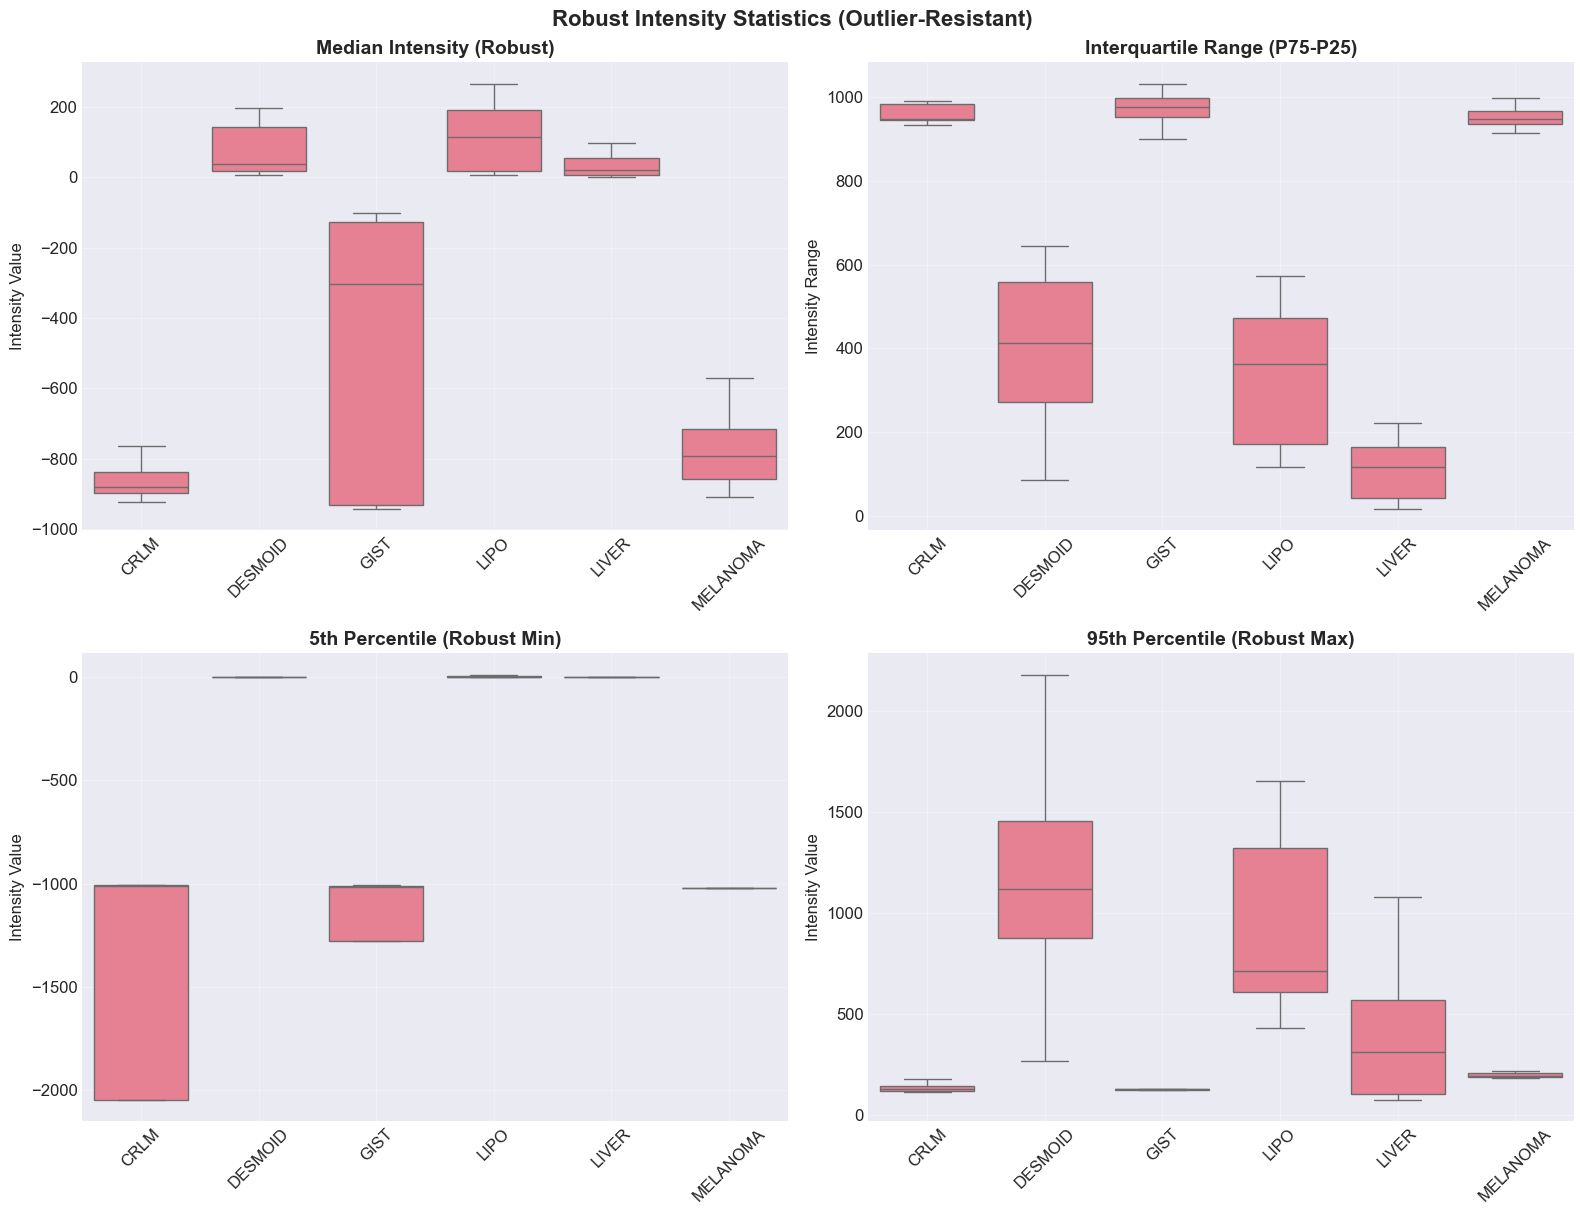


Robust Intensity Summary (Median and IQR) after outlier removal:
          Median (P50)         IQR           P5          P95
Dataset                                                     
CRLM       -843.625000  959.875000 -1399.375000   135.375000
DESMOID      78.204488  399.072503     0.000000  1149.944370
GIST       -471.875000  965.875000 -1273.500000   125.375000
LIPO        114.776648  339.442805     3.500000   917.661194
LIVER        32.333333  134.222222     0.111111   516.444444
MELANOMA   -747.750000  952.250000 -1023.875000   202.000000

✅ Robust intensity analysis complete!


In [13]:
# Robust intensity statistics using percentiles
print("Computing robust intensity statistics (using percentiles)...\n")

robust_intensity_data = []

for dataset_name, dataset_config in config['datasets'].items():
    print(f"Processing {dataset_name.upper()}...")
    
    images, labels = find_dataset_files(dataset_config, project_root)
    
    # Sample a few images for robust analysis
    sample_size = min(10, len(images))
    for img_path in images[:sample_size]:
        try:
            img_data = nib.load(img_path).get_fdata()
            
            # Use percentiles for robust statistics
            p1, p5, p25, p50, p75, p95, p99 = np.percentile(img_data, [1, 5, 25, 50, 75, 95, 99])
            
            robust_intensity_data.append({
                'Dataset': dataset_name.upper(),
                'P1': p1,
                'P5': p5,
                'P25': p25,
                'Median (P50)': p50,
                'P75': p75,
                'P95': p95,
                'P99': p99,
                'IQR': p75 - p25
            })
        except Exception as e:
            print(f"  ⚠️ Error loading {img_path.name}: {e}")

if robust_intensity_data:
    robust_df = pd.DataFrame(robust_intensity_data)
    metrics_for_outliers = ['Median (P50)', 'IQR', 'P5', 'P95']
    
    def remove_outliers_by_dataset(df, metrics):
        keep_indices = []
        removed = 0
        for dataset, group in df.groupby('Dataset'):
            mask = np.ones(len(group), dtype=bool)
            for metric in metrics:
                q1 = group[metric].quantile(0.25)
                q3 = group[metric].quantile(0.75)
                iqr = q3 - q1
                if iqr == 0:
                    continue
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr
                mask &= group[metric].between(lower, upper, inclusive='both')
            keep_indices.extend(group[mask].index)
            removed += (~mask).sum()
        clean_df = df.loc[sorted(keep_indices)]
        return clean_df, removed
    
    clean_df, removed_count = remove_outliers_by_dataset(robust_df, metrics_for_outliers)
    print(f"\nRemoved {removed_count} outlier samples out of {len(robust_df)} using per-dataset IQR filtering.")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Median intensity
    ax = axes[0, 0]
    sns.boxplot(data=clean_df, x='Dataset', y='Median (P50)', ax=ax, showfliers=False)
    ax.set_title('Median Intensity (Robust)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Intensity Value')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # IQR (P75 - P25)
    ax = axes[0, 1]
    sns.boxplot(data=clean_df, x='Dataset', y='IQR', ax=ax, showfliers=False)
    ax.set_title('Interquartile Range (P75-P25)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Intensity Range')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # 5th percentile (lower bound)
    ax = axes[1, 0]
    sns.boxplot(data=clean_df, x='Dataset', y='P5', ax=ax, showfliers=False)
    ax.set_title('5th Percentile (Robust Min)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Intensity Value')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # 95th percentile (upper bound)
    ax = axes[1, 1]
    sns.boxplot(data=clean_df, x='Dataset', y='P95', ax=ax, showfliers=False)
    ax.set_title('95th Percentile (Robust Max)', fontweight='bold', fontsize=14)
    ax.set_ylabel('Intensity Value')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Robust Intensity Statistics (Outlier-Resistant)',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.show()
    
    print("\nRobust Intensity Summary (Median and IQR) after outlier removal:")
    print(clean_df.groupby('Dataset')[['Median (P50)', 'IQR', 'P5', 'P95']].mean())
else:
    print("⚠️ No intensity data available")

print("\n✅ Robust intensity analysis complete!")

## Comprehensive Summary Table

In [14]:
# Create comprehensive summary table
summary_rows = []

for name, stats in dataset_stats.items():
    row = {'Dataset': name.upper()}
    
    # Counts
    row['N Images'] = stats['n_images']
    row['N Labels'] = stats['n_labels']
    
    # Dimensions
    if stats['shapes']:
        shapes = np.array(stats['shapes'])
        row['Mean D'] = f"{shapes[:, 0].mean():.0f}"
        row['Mean H'] = f"{shapes[:, 1].mean():.0f}"
        row['Mean W'] = f"{shapes[:, 2].mean():.0f}"
    else:
        row['Mean D'] = 'N/A'
        row['Mean H'] = 'N/A'
        row['Mean W'] = 'N/A'
    
    # Spacing
    if stats['spacings']:
        spacings = np.array(stats['spacings'])
        row['Spacing X'] = f"{spacings[:, 0].mean():.2f}"
        row['Spacing Y'] = f"{spacings[:, 1].mean():.2f}"
        row['Spacing Z'] = f"{spacings[:, 2].mean():.2f}"
    else:
        row['Spacing X'] = 'N/A'
        row['Spacing Y'] = 'N/A'
        row['Spacing Z'] = 'N/A'
    
    # Tumor volumes (physical)
    if stats.get('tumor_volumes_cm3'):
        row['Median Tumor Vol (cm³)'] = f"{np.median(stats['tumor_volumes_cm3']):.2f}"
        row['Median Tumor Vol (voxels)'] = f"{np.median(stats['tumor_volumes_voxels']):.0f}"
    else:
        row['Median Tumor Vol (cm³)'] = 'N/A'
        row['Median Tumor Vol (voxels)'] = 'N/A'
    
    summary_rows.append(row)

comprehensive_df = pd.DataFrame(summary_rows)

print("\n" + "="*100)
print("📊 COMPREHENSIVE DATASET SUMMARY")
print("="*100)
print(comprehensive_df.to_string(index=False))
print("="*100)


📊 COMPREHENSIVE DATASET SUMMARY
 Dataset  N Images  N Labels Mean D Mean H Mean W Spacing X Spacing Y Spacing Z Median Tumor Vol (cm³) Median Tumor Vol (voxels)
    CRLM        77        77    512    512    115      0.72      0.72      6.45                   9.26                      5033
 DESMOID       203       203    472    438     36      0.69      0.69      5.58                  59.92                     25532
    GIST       246       246    512    512    143      0.80      0.80      3.60                  75.24                     25116
    LIPO       115       115    448    416     37      0.64      0.64      5.84                 273.68                     90723
   LIVER       186       186    502    480     30      0.81      0.81      7.56                 128.43                     31209
MELANOMA       103       103    512    512    234      0.69      0.69      1.32                   1.79                      2362


## Summary

This notebook provides:
- ✅ Dataset inventory and file counts
- ✅ Volume dimension analysis
- ✅ Intensity distribution analysis
- ✅ Voxel spacing analysis
- ✅ Tumor volume statistics
- ✅ Visual samples from each dataset

Use this analysis to:
- Understand dataset characteristics
- Identify preprocessing needs
- Plan visualization strategies
- Quality check data availability